In [2]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import keras
import keras.backend as K
import sys
import uqmodels as uqmodels

path = '.'
storing = path + '/data/'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import uqmodels.processing as proc 
import uqmodels.preprocessing.Preprocessor as preproc
from uqmodels.processing import Data_loader
from uqmodels.processing import Pipeline
from uqmodels.preprocessing.Custom_Preprocessor import dict_to_TS_Dataset
import pandas as pd

#Data loading & Preprocessing
storing = 'data/'
filename = 'synthetic_dataset_multivariate.p'

# Instanciate Data_loader 
data_loader = Data_loader()

# Apply data_loader to get rowdata
dict_data = data_loader.load({'storing':storing,'keys':[filename]})
preprocessor = dict_to_TS_Dataset()
pipeline = Pipeline(data_loader=data_loader,list_processors=[preprocessor])
#Define query link to load api and add a 'name' key which is recover by the preprocessor to provide a name to the dataset
list_query = [{'storing':storing,'keys':[filename],'name':'Synthetic_data'}]

#It provide a data_generator (yield) that provide each processed data one by one.
dataset_generator = pipeline.transform(list_query) 

# Execute preprocessing pipeline :  
X, y, sample_weight, x_split, context, objective, name = next(dataset_generator)
train = x_split==1
test = np.invert(train)
print('X shape:',X.shape,'y: yshape',y.shape,'Name:',name)

Pipeline : No cache data found : load data and execute the whole pipeline
X shape: (12000, 19) y: yshape (12000, 3) Name: Synthetic_data


# RF-UQ 

Root mean square [array([0.35454324, 0.30451329, 0.31963972]), array([0.46449333, 0.40585166, 0.43980308])]
UQ_average_coverage [array([0.994   , 0.9955  , 0.995375]), array([0.97825, 0.97675, 0.97675])]


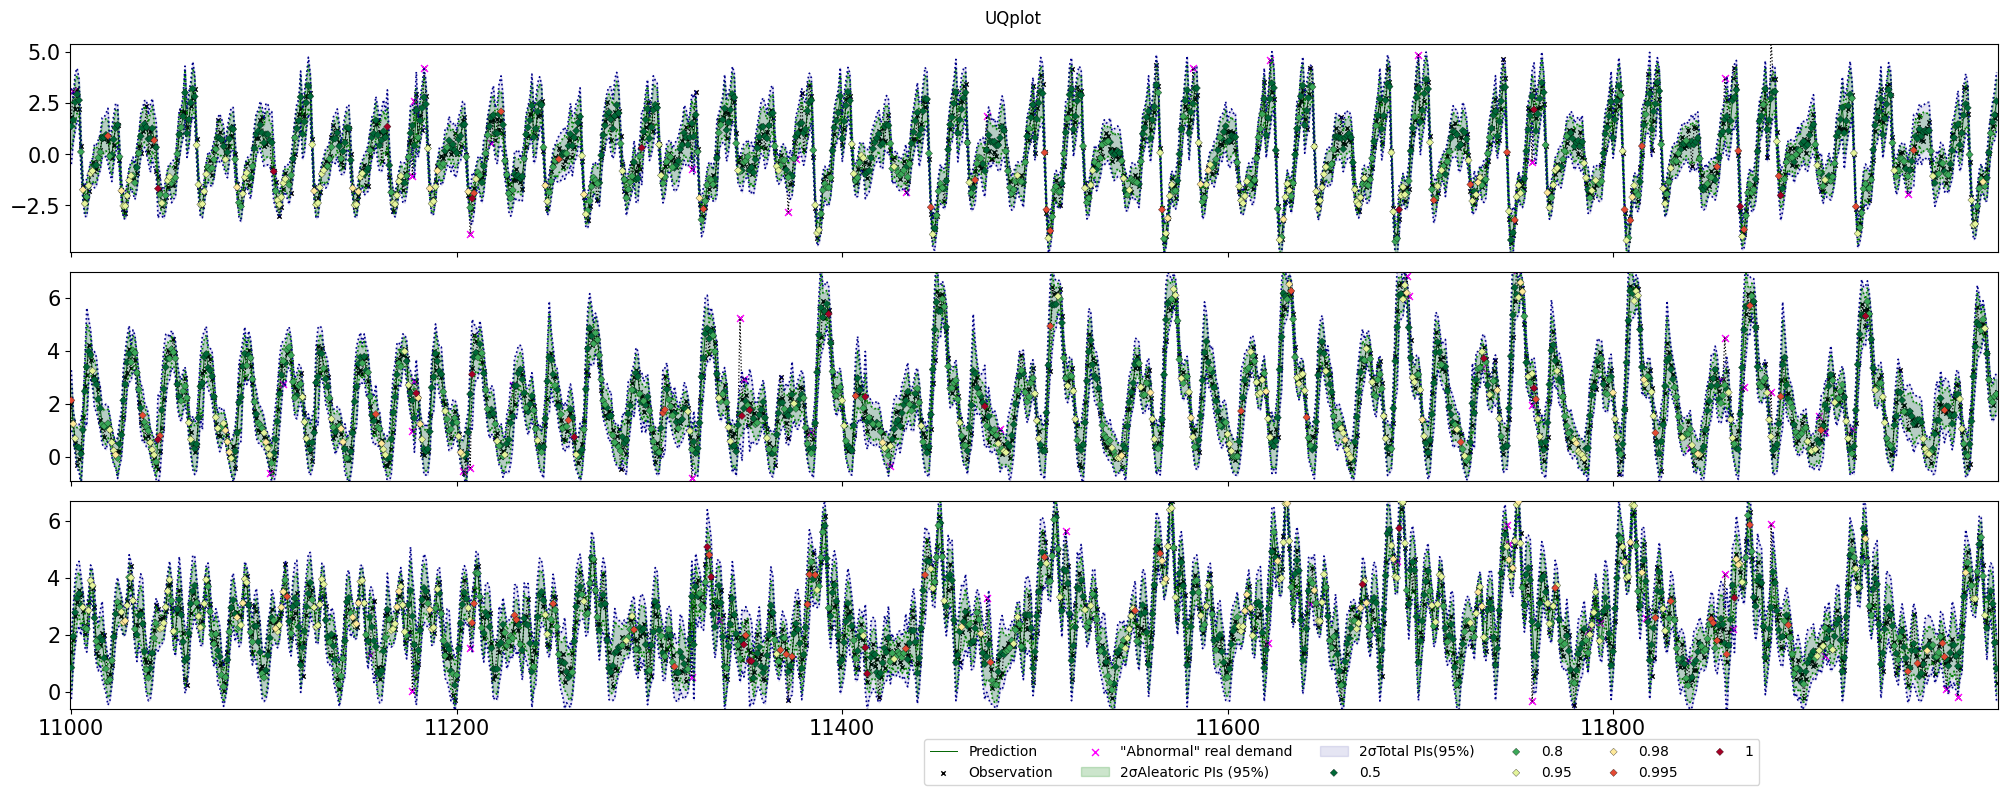

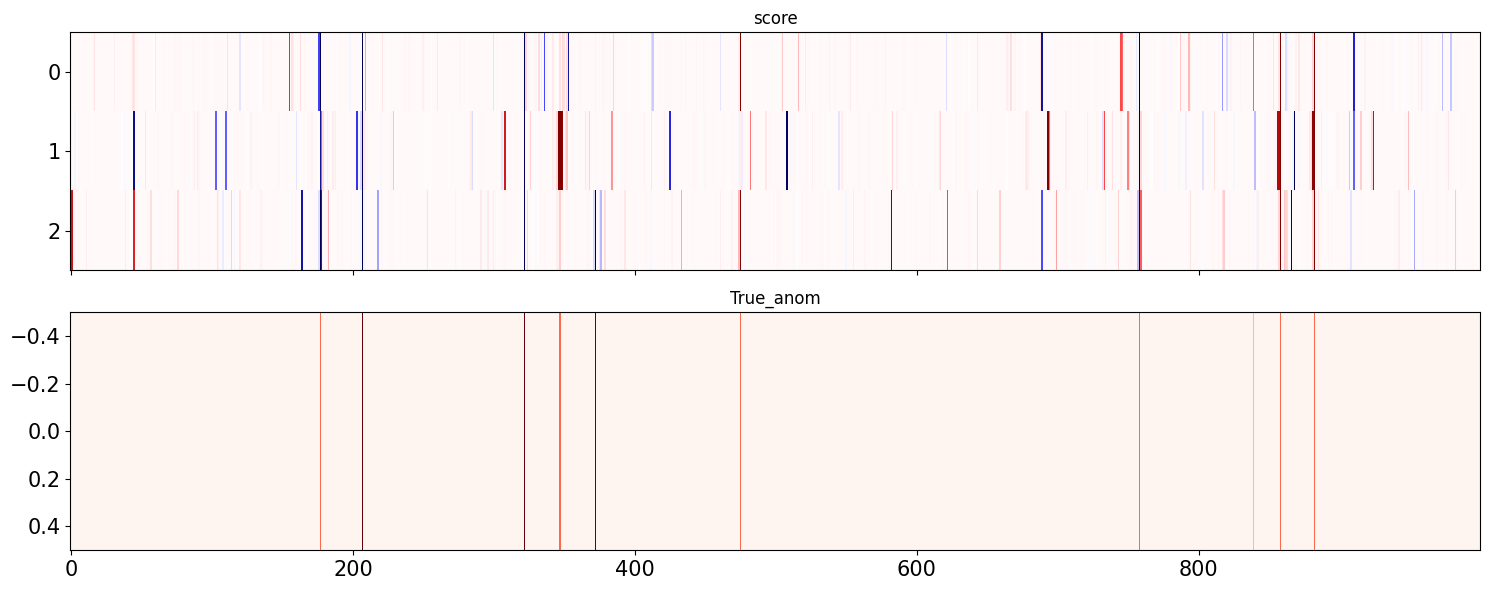

target [0.025, 0.16, 0.84, 0.975] empirique [0.006027777777777778, 0.07030555555555555, 0.9316666666666666, 0.9941388888888889]
target elvl [0.5, 0.8, 0.95, 0.98, 0.995, 1] empirique Elvl [0.0, 2.0, 3.0, 4.0, 5.0, 6.0]


In [4]:
from uqmodels.modelization.ML_estimator.random_forest_UQ import RF_UQEstimator,get_params_dict
from uqmodels.processing import Cache_manager
from uqmodels.custom_UQModel import UQModel_KPI,UQModel
# We can also create a more complexe UQmodel that handle several UQKPI_Processor to build at inference (UQMesure, Predictive interval and model unreliability score) and after observation (Anomaly score)

# Specification of the UQestimator & Instanciation in a UQmodels wrapper that include post-processing
RF_UQ_parameters = get_params_dict()
RF_UQModel = UQModel_KPI(RF_UQEstimator,
                         RF_UQ_parameters,
                         name='RF_UQ',
                         beta=0.005,
                         reduc_filter_KPI=None,
                         reduc_filter_pred=None,
                         cache_manager=Cache_manager(storing='model/'),
                         random_state=0)

RF_UQModel.fit(X[train],y[train])
if(True): # Test load save UQModels wrapper procedure
    # Save fitted UQEstimator and KPI-Processors
    RF_UQModel.save('model/')
    del RF_UQModel
    # New model 
    RF_UQModel = UQModel()

    # Load fitted UQEstimator and KPI-Processors
    RF_UQModel.load('model/RF_UQ')

#pred,((pred,UQ),PIs,Elvl) = RF_UQModel.predict(X,y)
(pred,UQ),KPI_anom,PIs,Elvl = RF_UQModel.score(X,y)

from uqmodels.evaluation.metrics import Generic_metric, rmse, UQ_average_coverage, UQ_sharpness, UQ_Gaussian_NLL, UQ_dEI, UQ_absolute_residu_score
from uqmodels.evaluation.evaluation import evaluate

if(True):
    list_metrics=[Generic_metric(rmse,'Root mean square',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E'),
                  Generic_metric(UQ_average_coverage,'UQ_average_coverage',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E')]
    output = pred,UQ
    metrics_val = evaluate(y,output,list_metrics,list_sets=[train,test],verbose=True)
    
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import uqmodels.visualization.visualization as visu

f_obs = np.arange(len(train))[-1000:]
list_percent = RF_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
visu.uncertainty_plot(y,output,context=None,size=(20,8),f_obs=f_obs,name='UQplot',mode_res=False,dim=np.arange(y.shape[1]),type_UQ=RF_UQModel.type_UQ,list_percent=list_percent)
visu.plot_anom_matrice(score=KPI_anom,true_label=dict_data['aux']['anom'][:,None],f_obs=f_obs)

list_alpha = RF_UQModel.list_predict_KPI_processors[1].KPI_parameters['list_alpha']
print('target', list_alpha, 'empirique', [(pi>y).mean() for pi in PIs])
list_percent = RF_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
print('target elvl',list_percent,'empirique Elvl',[np.quantile(Elvl,q) for q in list_percent])
del RF_UQModel

# NN_UQ for multi meta-moddeling paradigm 

In [5]:
#tf.keras.utils.get_custom_objects().clear()
from uqmodels.modelization.DL_estimator.neural_network_UQ import NN_UQ,get_params_dict,get_training_parameters,get_UQEstimator_parameters
from uqmodels.modelization.DL_estimator.metalayers import mlp
from uqmodels.processing import Cache_manager
from uqmodels.UQModel import UQModel
from uqmodels.custom_UQModel import UQModel_KPI
# We can also create a more complexe UQmodel that handle several UQKPI_Processor to build at inference (UQMesure, Predictive interval and model unreliability score) and after observation (Anomaly score)

# Specification of the UQestimator & Instanciation in a UQmodels wrapper that include post-processing
    
def run_mlp(type_output='MC_Dropout'):
    name = 'MLP_'+type_output
    print(type_output)
    mlp_params = get_params_dict(X.shape[1],y.shape[1],type_output=type_output)
    training_params = get_training_parameters(epochs=[20,10],b_s=[128,64],l_r=[0.001,0.0005],type_output=type_output)

    UQEstimator_parameters = get_UQEstimator_parameters(model_parameters=mlp_params, 
                                                    training_parameters=training_params,
                                                    type_output=type_output,
                                                    rescale=True,
                                                    model_initializer=mlp)

    MLP_UQModel = UQModel_KPI(UQEstimator_initializer=NN_UQ,
                             UQEstimator_params=UQEstimator_parameters,
                             name=name,
                             beta=0.005,
                             reduc_filter_KPI=None,
                             reduc_filter_pred=None,
                             cache_manager=Cache_manager(storing='model/'),
                             random_state=0)


    MLP_UQModel.fit(X[train],y[train],verbose=1)
    
    if(True): # Test save load procedure 
        MLP_UQModel.save('model/')
        del MLP_UQModel
        MLP_UQModel = UQModel()
        MLP_UQModel.load('model/'+name)
        
    #pred,((pred,UQ),PIs,Elvl) = RF_UQModel.predict(X,y)
    (pred,UQ),KPI_anom,PIs,Elvl = MLP_UQModel.score(X,y)

    from uqmodels.evaluation.metrics import Generic_metric, rmse, UQ_average_coverage, UQ_sharpness, UQ_Gaussian_NLL, UQ_dEI, UQ_absolute_residu_score
    from uqmodels.evaluation.evaluation import evaluate

    if(True):
        list_metrics=[Generic_metric(rmse,'Root mean square',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E'),
                      Generic_metric(UQ_average_coverage,'UQ_average_coverage',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E')]
        output = pred,UQ
        metrics_val = evaluate(y,output,list_metrics,list_sets=[train,test],verbose=True)

    %matplotlib notebook
    %matplotlib inline
    import matplotlib.pyplot as plt
    import uqmodels.visualization.visualization as visu

    f_obs = np.arange(len(train))[-1000:]
    list_percent = MLP_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
    visu.uncertainty_plot(y,output,context=None,size=(20,8),f_obs=f_obs,name='UQplot',mode_res=False,dim=np.arange(y.shape[1]),type_UQ=MLP_UQModel.type_UQ,list_percent=list_percent,confidence_lvl=Elvl)
    visu.plot_anom_matrice(score=KPI_anom,true_label=dict_data['aux']['anom'][:,None],f_obs=f_obs)

    list_alpha = MLP_UQModel.list_predict_KPI_processors[1].KPI_parameters['list_alpha']
    print('target', list_alpha, 'empirique', [(pi>y).mean() for pi in PIs])
    list_percent = MLP_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
    print('target elvl',list_percent,'empirique Elvl',[np.quantile(Elvl,q) for q in list_percent])
    del MLP_UQModel

In [6]:
# MLP_UQ_MC_Dropout

MC_Dropout
start_fit


/home/kevin.pasini/miniforge3/envs/uqmodels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
I0000 00:00:1764759248.791682   62955 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43823 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:00:05.0, compute capability: 8.6


Epoch 1/20


2025-12-03 10:54:10.166327: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


55/57 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - bnn_loss: 0.9695 - loss: 0.6157 - mse_loss: 0.7337

...

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - bnn_loss: 0.9811 - loss: -0.6796 - mse_loss: 0.3393 - val_bnn_loss: 0.9882 - val_loss: -1.1903 - val_mse_loss: 0.2840 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - bnn_loss: 0.9714 - loss: -1.0046 - mse_loss: 0.3322 - val_bnn_loss: 0.9888 - val_loss: -1.2861 - val_mse_loss: 0.2781 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - bnn_loss: 0.9716 - loss: -1.0751 - mse_loss: 0.3250 - val_bnn_loss: 0.9877 - val_loss: -1.3098 - val_mse_loss: 0.2798 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - bnn_loss: 0.9678 - loss: -1.1275 - mse_loss: 0.3196 - val_bnn_loss: 0.9874 - val_loss: -1.3133 - val_mse_loss: 0.2851 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - bnn_loss: 0.9673 - loss: -1.1584 - mse_loss: 0.3147 - val_bnn_loss: 0.9870 - val_loss: -1.3612 - val_mse_loss: 0.2764 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━

2025-12-03 10:55:12.077548: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - bnn_loss: 0.9636 - loss: -1.3180 - mse_loss: 0.2970 - val_bnn_loss: 0.9792 - val_loss: -1.4761 - val_mse_loss: 0.2696 - learning_rate: 5.0000e-04
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - bnn_loss: 0.9655 - loss: -1.3153 - mse_loss: 0.2966 - val_bnn_loss: 0.9792 - val_loss: -1.4965 - val_mse_loss: 0.2705 - learning_rate: 5.0000e-04
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - bnn_loss: 0.9637 - loss: -1.3382 - mse_loss: 0.2943 - val_bnn_loss: 0.9808 - val_loss: -1.4854 - val_mse_loss: 0.2710 - learning_rate: 5.0000e-04
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - bnn_loss: 0.9645 - loss: -1.3288 - mse_loss: 0.2944 - val_bnn_loss: 0.9808 - val_loss: -1.4750 - val_mse_loss: 0.2714 - learning_rate: 5.0000e-04
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - bnn_loss: 0.9640 - loss: -1.3334 - mse_loss: 0.2953 - val_bnn_loss: 0.9812 - val_loss: -1.4646 - val_mse_loss: 0.2720 - learning_rate: 5.0000e-04
Epoch 

/home/kevin.pasini/miniforge3/envs/uqmodels/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/kevin.pasini/miniforge3/envs/uqmodels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
Root mean square [array([0.41728576, 0.35763005, 0.38466665]), array([0.45669414, 0.38823195, 0.43045485])]
UQ_average_coverage [array([0.984875, 0.98575 , 0.986   ]), array([0.97625, 0.975  , 0.975  ])]


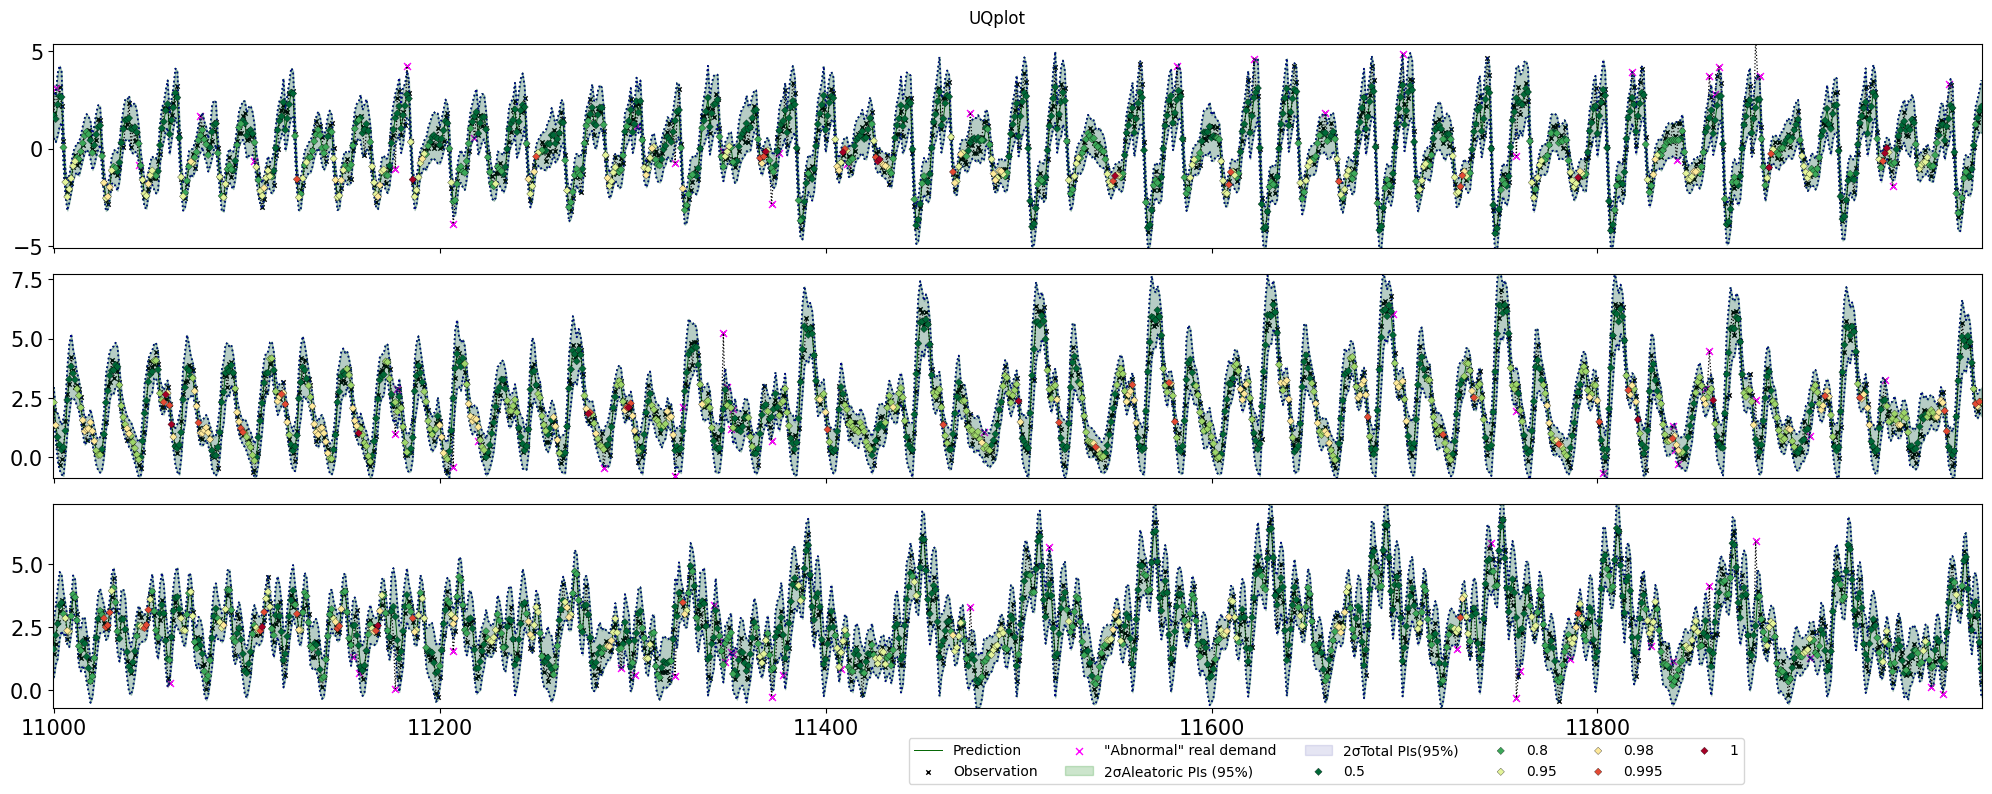

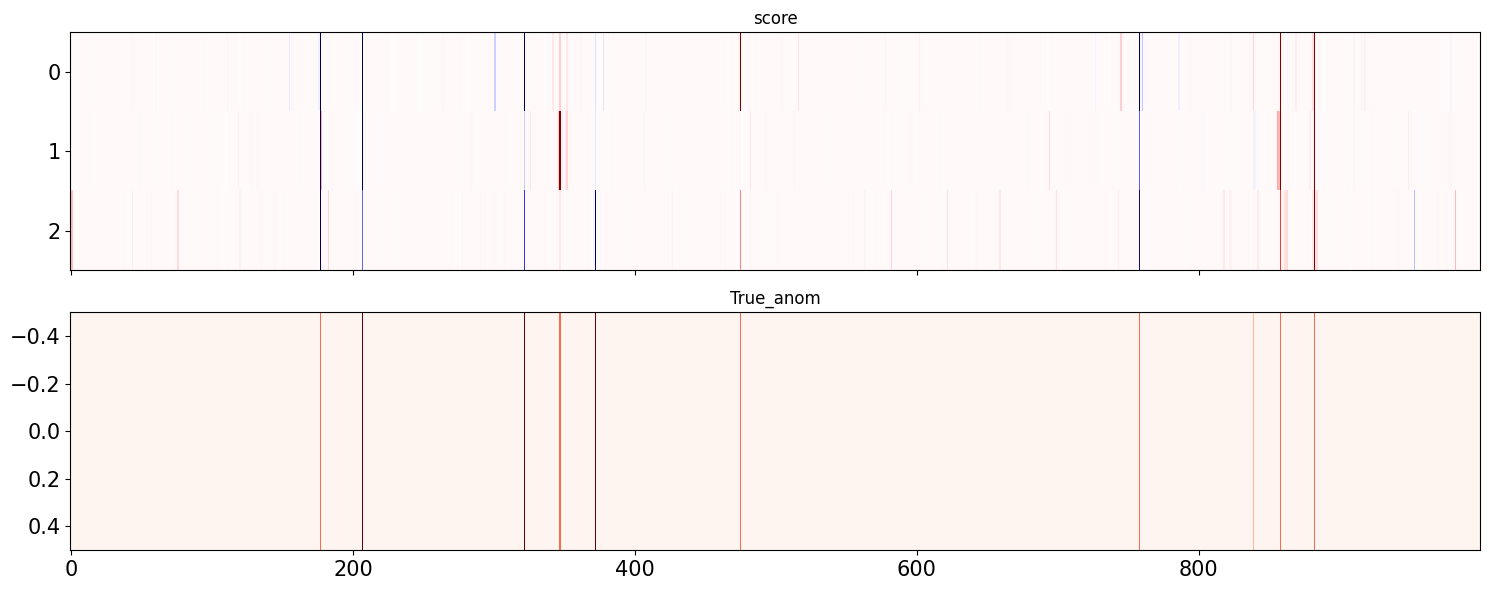

target [0.025, 0.16, 0.84, 0.975] empirique [0.010444444444444444, 0.1005, 0.915, 0.99075]
target elvl [0.5, 0.8, 0.95, 0.98, 0.995, 1] empirique Elvl [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


In [7]:
run_mlp(type_output='MC_Dropout')

# MLP_UQ_Deep_ensemble

In [ ]:
run_mlp(type_output='Deep_ensemble')

Deep_ensemble
start_fit


/home/kevin.pasini/miniforge3/envs/uqmodels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/20


2025-12-03 10:55:46.928918: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - bnn_loss: 0.9905 - loss: 0.3203 - mse_loss: 0.4989 - val_bnn_loss: 0.9989 - val_loss: 0.1603 - val_mse_loss: 0.3470 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - bnn_loss: 0.9979 - loss: 0.1629 - mse_loss: 0.3524 - val_bnn_loss: 0.9993 - val_loss: 0.1411 - val_mse_loss: 0.3191 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - bnn_loss: 0.9985 - loss: 0.1473 - mse_loss: 0.3301 - val_bnn_loss: 0.9979 - val_loss: 0.1337 - val_mse_loss: 0.3076 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - bnn_loss: 0.9987 - loss: 0.1396 - mse_loss: 0.3193 - val_bnn_loss: 0.9989 - val_loss: 0.1283 - val_mse_loss: 0.2990 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - bnn_loss: 0.9989 - loss: 0.1333 - mse_loss: 0.3100 - val_bnn_loss: 0.9989 - val_loss: 0.1242 - val_mse_loss: 0.2927 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/

...

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - bnn_loss: 0.9996 - loss: 0.1039 - mse_loss: 0.2682 - val_bnn_loss: 0.9992 - val_loss: 0.1061 - val_mse_loss: 0.2716 - learning_rate: 5.0000e-04
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - bnn_loss: 0.9996 - loss: 0.1027 - mse_loss: 0.2665 - val_bnn_loss: 0.9988 - val_loss: 0.1063 - val_mse_loss: 0.2723 - learning_rate: 5.0000e-04
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - bnn_loss: 0.9995 - loss: 0.1019 - mse_loss: 0.2655 - val_bnn_loss: 0.9988 - val_loss: 0.1061 - val_mse_loss: 0.2725 - learning_rate: 5.0000e-04
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - bnn_loss: 0.9995 - loss: 0.1015 - mse_loss: 0.2650 - val_bnn_loss: 0.9988 - val_loss: 0.1057 - val_mse_loss: 0.2722 - learning_rate: 5.0000e-04
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - bnn_loss: 0.9994 - loss: 0.1009 - mse_loss: 0.2643 - val_bnn_loss: 0.9988 - val_loss: 0.1045 - val_mse_loss: 0.2706 - learning_rate: 5.0000e-04
Epoch 6/10
113/1

2025-12-03 10:56:25.190457: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - bnn_loss: 0.9775 - loss: -1.0100 - mse_loss: 0.2920 - val_bnn_loss: 0.9745 - val_loss: -1.4048 - val_mse_loss: 0.2738 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - bnn_loss: 0.9695 - loss: -1.3516 - mse_loss: 0.2807 - val_bnn_loss: 0.9694 - val_loss: -1.4568 - val_mse_loss: 0.2737 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - bnn_loss: 0.9681 - loss: -1.4213 - mse_loss: 0.2760 - val_bnn_loss: 0.9701 - val_loss: -1.5071 - val_mse_loss: 0.2706 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - bnn_loss: 0.9673 - loss: -1.4743 - mse_loss: 0.2710 - val_bnn_loss: 0.9683 - val_loss: -1.5092 - val_mse_loss: 0.2723 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - bnn_loss: 0.9672 - loss: -1.4865 - mse_loss: 0.2700 - val_bnn_loss: 0.9698 - val_loss: -1.5367 - val_mse_loss: 0.2680 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━

2025-12-03 10:56:46.729152: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - bnn_loss: 0.9652 - loss: -1.6897 - mse_loss: 0.2503 - val_bnn_loss: 0.9574 - val_loss: -1.5242 - val_mse_loss: 0.2713 - learning_rate: 5.0000e-04
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - bnn_loss: 0.9643 - loss: -1.6914 - mse_loss: 0.2510 - val_bnn_loss: 0.9586 - val_loss: -1.5237 - val_mse_loss: 0.2706 - learning_rate: 5.0000e-04
Epoch 3/10
 81/113 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - bnn_loss: 0.9664 - loss: -1.7120 - mse_loss: 0.2440

In [ ]:
# MLP_UQ_Deep_ensemble

In [ ]:
run_mlp(type_output='EDL')

# LSTM_ED_UQ mutlihorizon forecast as UQEstimator

In [ ]:
from uqmodels.modelization.DL_estimator.lstm_ed import Lstm_ED_UQ,get_training_parameters,get_UQEstimator_parameters,get_params_dict
from uqmodels.custom_UQModel import UQModel, UQModel_KPI

name = 'LSTM_ED'
type_output = 'MC_Dropout'
model_params = get_params_dict(dim_ctx=X.shape[-1], dim_dyn=y.shape[-1],dim_target=y.shape[-1],size_window=40,n_windows=10,dim_horizon=5,dim_chan=1,type_output='MC_Dropout')
training_param = get_training_parameters(epochs=[20,10],b_s=[128,64],l_r=[0.001,0.0005],list_loss=['MSE','BNN'],metrics=['MSE','BNN'],param_loss=[2,0.9])
UQEstimator_initializer = Lstm_ED_UQ

UQEstimator_parameters = get_UQEstimator_parameters(model_parameters=model_params, 
                                                    training_parameters=training_param,
                                                    type_output=type_output,
                                                    factory_parameters= {'factory_lag_st':0,'factory_lag_lt':0},
                                                    rescale=False)


# We can also create a more complexe UQmodel that handle several UQKPI_Processor to build at inference (UQMesure, Predictive interval and model unreliability score) and after observation (Anomaly score)

# Specification of the UQestimator
UQEstimator_initializer = UQEstimator_initializer
UQEstimator_parameters = UQEstimator_parameters

# Instanciation of the UQmodel modeling pipeline
DEEP_UQModel = UQModel_KPI(UQEstimator_initializer,
                           UQEstimator_parameters,
                           name=name, 
                           predictor=None,
                           beta=0.001,reduc_filter_KPI=[1,1,1,1,1],
                           reduc_filter_pred=[1,0,0,0,0],
                           random_state=0)

# Fit procedure

# Apply factory at begin on all sub-sequences, then learning using folded representation : lot of space memory / less time consuming
DEEP_UQModel._init_UQEstimator((X[train],y[train]),y[train])

# Afactory function turn sequence in Window with mutli-horizon prediction
# Manipulate sequence and apply factory on each batch : Less space memory / more time consuming
if True : # For test purpose run both mode
    DEEP_UQModel.UQEstimator.training_parameters['generator']=True
    DEEP_UQModel.fit([X[train],y[train]],y[train],verbose=1)
    pred,(UQ,PIs,Elvl) = DEEP_UQModel.predict((X,y))
    (pred,UQ),KPI_anom,PIs,Elvl = DEEP_UQModel.score((X,y),y)

# Apply factory on all sub-sequences, then learning on batch representation : lot of space memory / less time consuming
if True :
    DEEP_UQModel.UQEstimator.training_parameters['generator']=False
    DEEP_UQModel._init_UQEstimator((X[train],y[train]),y[train])
    DEEP_UQModel.fit([X[train],y[train]],y[train],verbose=1)
    if(True): # Test save load procedure 
        DEEP_UQModel.save('model/')
        del DEEP_UQModel
        DEEP_UQModel = UQModel()
        DEEP_UQModel.load('model/'+name)
    pred,(UQ,PIs,Elvl) = DEEP_UQModel.predict((X,y))
    (pred,UQ),KPI_anom,PIs,Elvl = DEEP_UQModel.score((X,y),y)
# Inference procedure that provide prediction plus the specified UQKPIs


from uqmodels.evaluation.metrics import Generic_metric, rmse, UQ_average_coverage, UQ_sharpness, UQ_Gaussian_NLL, UQ_dEI, UQ_absolute_residu_score
from uqmodels.evaluation.evaluation import evaluate
if(True):
    list_metrics=[Generic_metric(rmse,'Root mean square',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E'),
                  Generic_metric(UQ_average_coverage,'UQ_average_coverage',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E')]
    output = pred,UQ
    metrics_val = evaluate(y,output,list_metrics,list_sets=[train,test],verbose=True)
    


In [ ]:
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import uqmodels.visualization.visualization as visu

f_obs = np.arange(len(train))[-1000:]

list_percent = DEEP_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
visu.uncertainty_plot(y,output,context=None,size=(20,8),f_obs=f_obs,name='UQplot',mode_res=False,dim=np.arange(y.shape[1]),type_UQ=DEEP_UQModel.type_UQ,confidence_lvl=Elvl,list_percent=list_percent)
visu.plot_anom_matrice(score=KPI_anom,true_label=dict_data['aux']['anom'][:,None],f_obs=f_obs)

list_alpha = DEEP_UQModel.list_predict_KPI_processors[1].KPI_parameters['list_alpha']
print('target', list_alpha, 'empirique', [(pi>y).mean() for pi in PIs])
list_percent = DEEP_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
print('target elvl',list_percent,'empirique Elvl',[np.quantile(Elvl,q) for q in list_percent])
del DEEP_UQModel

In [ ]:
# LSTM_ED_UQ mutlihorizon forecast as UQEstimator

In [ ]:
from uqmodels.modelization.DL_estimator.loss import build_BNN_loss, build_MSE_loss, default_callbacks
from uqmodels.modelization.DL_estimator.transformer_ed import Transformer_ED_UQ,get_training_parameters,get_UQEstimator_parameters,get_params_dict
from uqmodels.custom_UQModel import UQModel, UQModel_KPI

name = 'Transformer_ED'
type_output = 'MC_Dropout'
model_params = get_params_dict(dim_ctx=X.shape[-1],dim_dyn=y.shape[-1],dim_target=y.shape[-1],size_window=40,n_windows=10,dim_horizon=5)
training_param = get_training_parameters(epochs=[20,10],b_s=[128],l_r=[0.001,0.0005],list_loss=['MSE','BNN'],metrics=['MSE','BNN'],param_loss=[2,0.9])
UQEstimator_initializer = Transformer_ED_UQ
UQEstimator_parameters = get_UQEstimator_parameters(model_parameters=model_params, 
                                                    training_parameters=training_param,
                                                    type_output=type_output,
                                                    factory_parameters= {'factory_lag_st':0,'factory_lag_lt':0},
                                                    rescale=False)


from uqmodels.custom_UQModel import UQModel_KPI
# We can also create a more complexe UQmodel that handle several UQKPI_Processor to build at inference (UQMesure, Predictive interval and model unreliability score) and after observation (Anomaly score)

# Specification of the UQestimator
UQEstimator_initializer = UQEstimator_initializer
UQEstimator_parameters = UQEstimator_parameters

# Instanciation of the UQmodel modeling pipeline
DEEP_UQModel = UQModel_KPI(UQEstimator_initializer,
                           UQEstimator_parameters,
                           name=name,
                           predictor=None,
                           beta=0.001,
                           reduc_filter_KPI=[1,1,1,1,1],
                           reduc_filter_pred=[1,0,0,0,0],
                           random_state=0)

# Fit procedure

# Apply factory at begin on all sub-sequences, then learning using folded representation : lot of space memory / less time consuming
DEEP_UQModel._init_UQEstimator((X[train],y[train]),y[train])

# Afactory function turn sequence in Window with mutli-horizon prediction
# Manipulate sequence and apply factory on each batch : Less space memory / more time consuming
if True : # For test purpose run both mode
    DEEP_UQModel.UQEstimator.training_parameters['generator']=True
    DEEP_UQModel.fit([X[train],y[train]],y[train],verbose=1)
    pred,(UQ,PIs,Elvl) = DEEP_UQModel.predict((X,y))
    (pred,UQ),KPI_anom,PIs,Elvl = DEEP_UQModel.score((X,y),y)

# Apply factory on all sub-sequences, then learning on batch representation : lot of space memory / less time consuming
if True :
    DEEP_UQModel.UQEstimator.training_parameters['generator']=False
    DEEP_UQModel.fit([X[train],y[train]],y[train],verbose=1)
    if(False): # Test save load procedure : issues laading procedure run but doesn't load an operational model 
        DEEP_UQModel.save('model/')
        DEEP_UQModel = UQModel()
        DEEP_UQModel.load('model/'+name+'/')
    pred,(UQ,PIs,Elvl) = DEEP_UQModel.predict((X,y))
    (pred,UQ),KPI_anom,PIs,Elvl = DEEP_UQModel.score((X,y),y)

# Inference procedure that provide prediction plus the specified UQKPIs
#pred,((pred,UQ),PIs,Elvl) = DEEP_UQModel.predict([X[train],y[train]])
# Score procedure that provide ANom-KPI

from uqmodels.evaluation.metrics import Generic_metric, rmse, UQ_average_coverage, UQ_sharpness, UQ_Gaussian_NLL, UQ_dEI, UQ_absolute_residu_score
from uqmodels.evaluation.evaluation import evaluate

list_metrics=[Generic_metric(rmse,'Root mean square',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E'),
              Generic_metric(UQ_average_coverage,'UQ_average_coverage',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E')]
output = pred,UQ
metrics_val = evaluate(y,output,list_metrics,list_sets=[train,test],verbose=True)




In [ ]:
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import uqmodels.visualization.visualization as visu

f_obs = np.arange(len(train))[-1000:]

list_percent = DEEP_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
visu.uncertainty_plot(y,output,context=None,size=(20,8),f_obs=f_obs,name='UQplot',mode_res=False,dim=np.arange(y.shape[1]),type_UQ=DEEP_UQModel.type_UQ,confidence_lvl=Elvl,list_percent=list_percent)
visu.plot_anom_matrice(score=KPI_anom,true_label=dict_data['aux']['anom'][:,None],f_obs=f_obs)

list_alpha = DEEP_UQModel.list_predict_KPI_processors[1].KPI_parameters['list_alpha']
print('target', list_alpha, 'empirique', [(pi>y).mean() for pi in PIs])
list_percent = DEEP_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
print('target elvl',list_percent,'empirique Elvl',[np.quantile(Elvl,q) for q in list_percent])


In [ ]:
del DEEP_UQModel